Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

Load the dataset

In [2]:
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["species"] = iris.target

df["species"] = df["species"].replace({
    0:"Setosa",
    1:"Versicolor",
    2:"Virginica"
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


Check dataset size

In [3]:
print(df.shape)

(150, 5)


Check dataset information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


Check missing values

In [5]:
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


Check missing values

In [6]:
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


Check duplicate rows

In [7]:
df.duplicated().sum()

np.int64(1)

Remove duplicates

In [8]:
df = df.drop_duplicates()

print(df.shape)

(149, 5)


Check data types

In [9]:
print(df.dtypes)

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species               object
dtype: object


Display descriptive statistics

In [10]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,149.000000,149.000000,149.000000,149.000000
mean,5.843624,3.059732,3.748993,1.194631
std,0.830851,0.436342,1.767791,0.762622
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.300000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Count each flower species

In [11]:
df["species"].value_counts()

,count
species,
Setosa,50
Versicolor,50
Virginica,49


Create a Count Plot

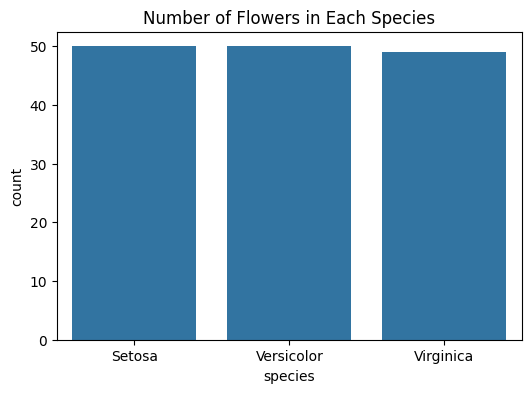

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="species")

plt.title("Number of Flowers in Each Species")

plt.show()

Create a Box Plot

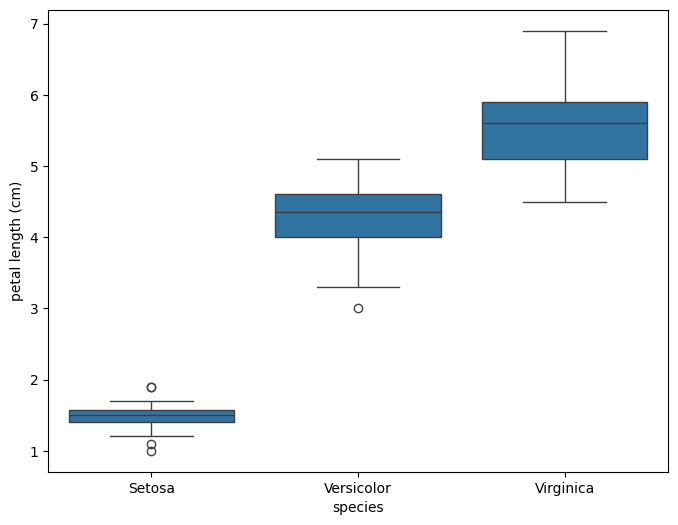

In [13]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="species",
    y="petal length (cm)"
)

plt.show()

Correlation Heatmap

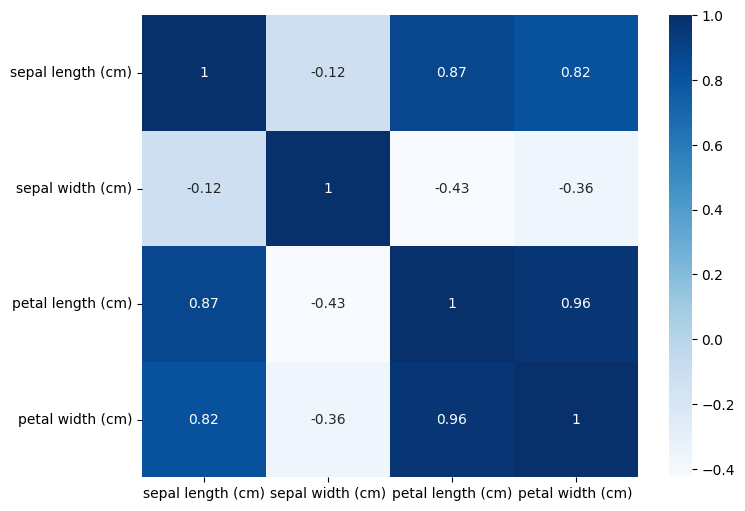

In [14]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.drop("species", axis=1).corr(),
    annot=True,
    cmap="Blues"
)

plt.show()

Pairplot

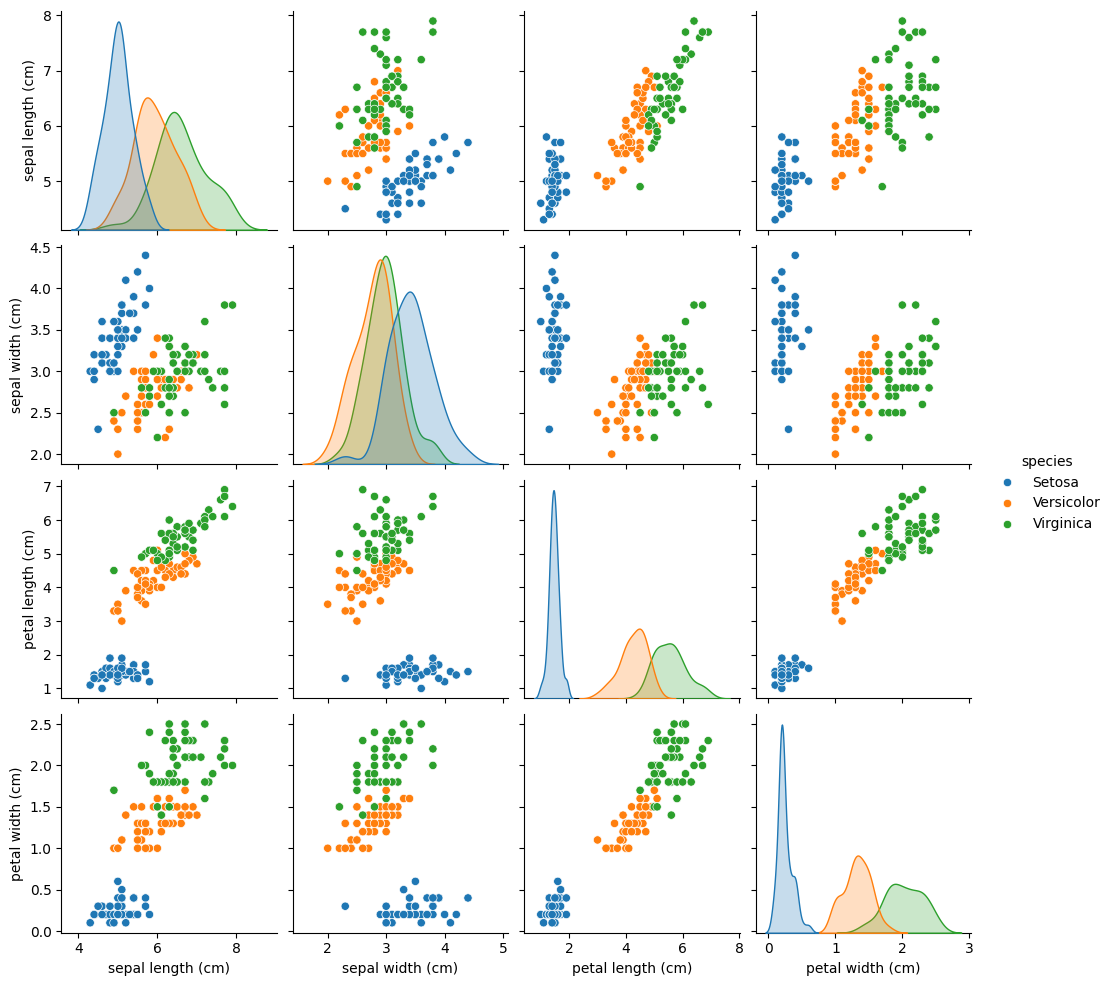

In [15]:
sns.pairplot(df, hue="species")

plt.show()

Save cleaned dataset

In [16]:
df.to_csv("cleaned_iris.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


Download cleaned dataset

In [17]:
from google.colab import files

files.download("cleaned_iris.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Load Titanic Dataset

In [18]:
df = sns.load_dataset("titanic")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Check Dataset Shape

In [19]:
print(df.shape)

(891, 15)


View Dataset Information

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


Check Missing Values

In [21]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


Display Missing Values as Percentages

In [22]:
missing = df.isnull().sum()/len(df)*100

missing.sort_values(ascending=False)

,0
deck,77.216611
age,19.865320
embarked,0.224467
embark_town,0.224467
sex,0.000000
pclass,0.000000
survived,0.000000
fare,0.000000
parch,0.000000
sibsp,0.000000


Remove Columns with too many missing values

In [23]:
df.drop(columns=["deck"], inplace=True)

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


Fill missing ages

In [24]:
df["age"] = df["age"].fillna(df["age"].median())

Fill missing embarked values

In [25]:
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

Fill missing embark town

In [26]:
df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])

Verify missing values are gone

In [27]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


Check for duplicate rows

In [28]:
df.duplicated().sum()

np.int64(116)

Remove duplicate rows

In [29]:
df = df.drop_duplicates()

print(df.shape)

(775, 14)


Check data types

In [30]:
df.dtypes

,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,category
who,object


Summary Statistics

In [31]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,775.000000,775.000000,775.000000,775.000000,775.000000,775.000000
mean,0.412903,2.246452,29.581187,0.529032,0.420645,34.878403
std,0.492674,0.853574,13.766359,0.990326,0.840565,52.408474
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,21.000000,0.000000,0.000000,8.050000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,15.900000
75%,1.000000,3.000000,36.000000,1.000000,1.000000,34.197900
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Exploratory Data Analysis: Survival Count

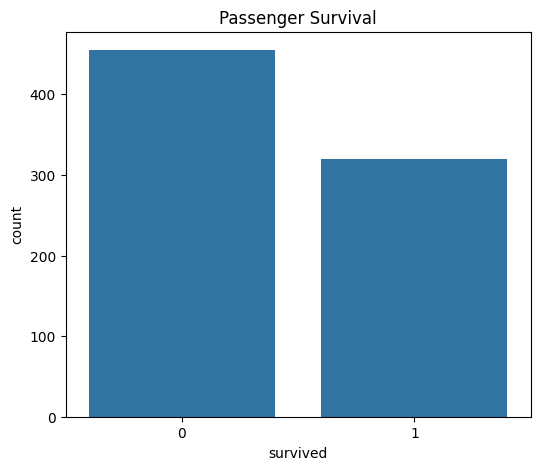

In [32]:
plt.figure(figsize=(6,5))

sns.countplot(data=df,
              x="survived")

plt.title("Passenger Survival")

plt.show()

Survival by Gender

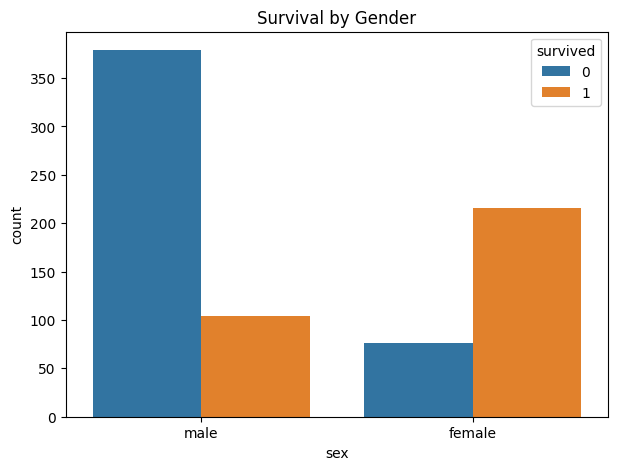

In [33]:
plt.figure(figsize=(7,5))

sns.countplot(data=df,
              x="sex",
              hue="survived")

plt.title("Survival by Gender")

plt.show()

Survival by Passenger Class

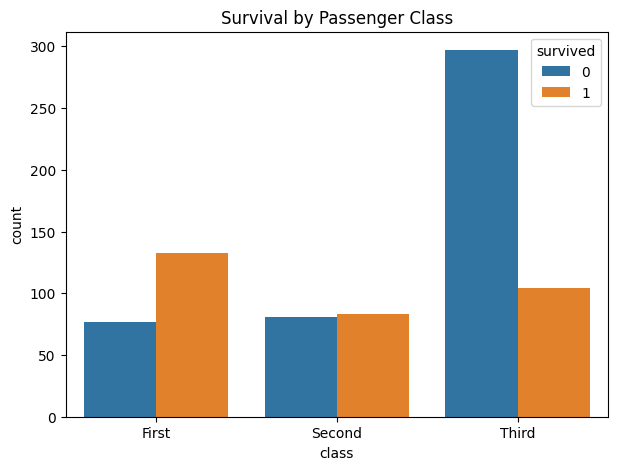

In [34]:
plt.figure(figsize=(7,5))

sns.countplot(data=df,
              x="class",
              hue="survived")

plt.title("Survival by Passenger Class")

plt.show()

Fare Distribution

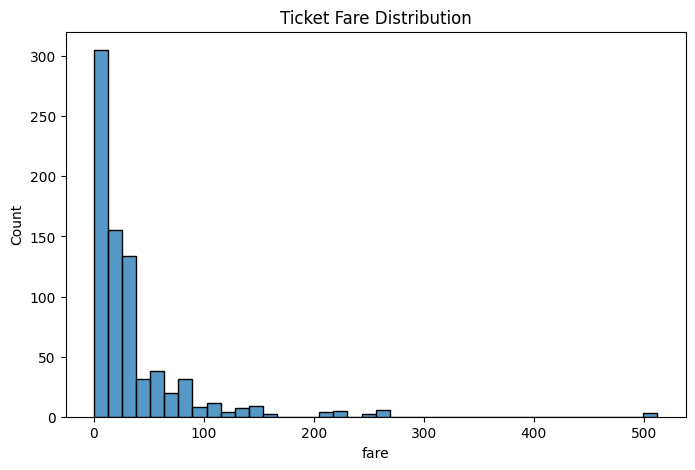

In [35]:
plt.figure(figsize=(8,5))

sns.histplot(df["fare"], bins=40)

plt.title("Ticket Fare Distribution")

plt.show()

Age Distribution

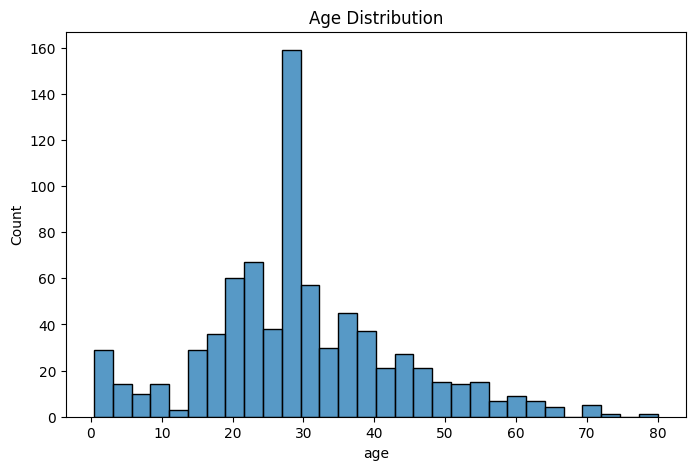

In [36]:
plt.figure(figsize=(8,5))

sns.histplot(df["age"], bins=30)

plt.title("Age Distribution")

plt.show()

Boxplot of age by passenger class

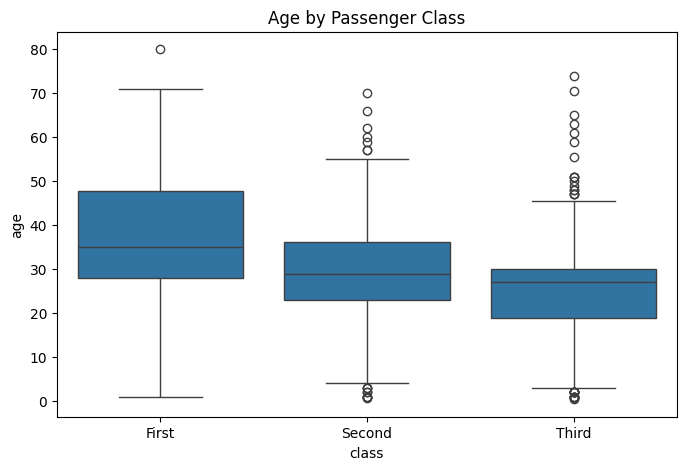

In [37]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="class",
    y="age"
)

plt.title("Age by Passenger Class")

plt.show()

Correlation Heatmap

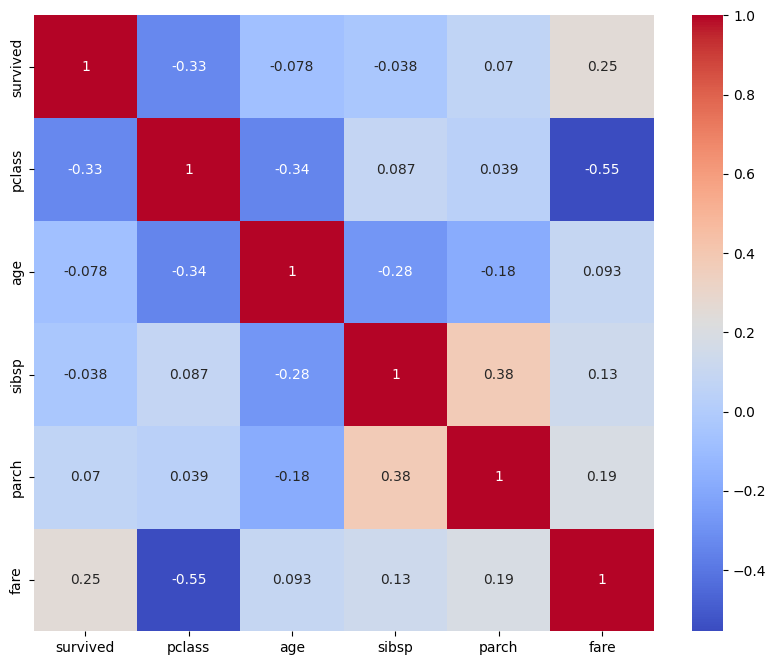

In [38]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

Save the cleaned dataset

In [39]:
df.to_csv("cleaned_titanic.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


Download cleaned dataset

In [40]:
from google.colab import files

files.download("cleaned_titanic.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Summary of Findings

1. The Titanic dataset originally contained missing values in the Age, Deck, Embarked, and Embark Town columns.

2. The Deck column had too many missing values and was removed.

3. Missing Age values were replaced with the median age.

4. Missing Embarked and Embark Town values were replaced with the most common value (mode).

5. Females had a significantly higher survival rate than males.

6. First-class passengers were more likely to survive than second- and third-class passengers.

7. Most passengers were between 20 and 40 years old.

8. Ticket fares were heavily skewed, with a few passengers paying very high fares.

9. The cleaned dataset is now ready for building machine learning models in Week 3.